In [ ]:
import numpy as np

def create_pd(minx, maxx):
    xnum = maxx - minx + 1
    X = np.arange(minx, maxx + 1)
    P = np.random.uniform(size=xnum)
    P /= np.sum(P)
    return X, P

In [2]:
np.random.seed(0)
X, P = create_pd(-10, 10)
for x, p in zip(X, P):
    print(f"P(X = {x:3d}) = {p:.5f}")
print(f"確率の合計 = {np.sum(P)}")

P(X = -10) = 0.04352
P(X =  -9) = 0.05672
P(X =  -8) = 0.04780
P(X =  -7) = 0.04321
P(X =  -6) = 0.03360
P(X =  -5) = 0.05122
P(X =  -4) = 0.03470
P(X =  -3) = 0.07072
P(X =  -2) = 0.07642
P(X =  -1) = 0.03041
P(X =   0) = 0.06279
P(X =   1) = 0.04194
P(X =   2) = 0.04505
P(X =   3) = 0.07340
P(X =   4) = 0.00563
P(X =   5) = 0.00691
P(X =   6) = 0.00160
P(X =   7) = 0.06603
P(X =   8) = 0.06171
P(X =   9) = 0.06900
P(X =  10) = 0.07761
確率の合計 = 0.9999999999999998


In [3]:
import matplotlib.pyplot as plt
import japanize_matplotlib

def show_pd(X, P, xlabel="X"):
    E = np.sum(X * P)
    V = np.sum(X * X * P) - E ** 2
    print(f"期待値 = {E:6.3f}")
    print(f"分散   = {V:6.3f}")
    plt.bar(X, P)
    plt.xlabel(xlabel)
    plt.ylabel("確率")

期待値 =  0.149
分散   = 39.856


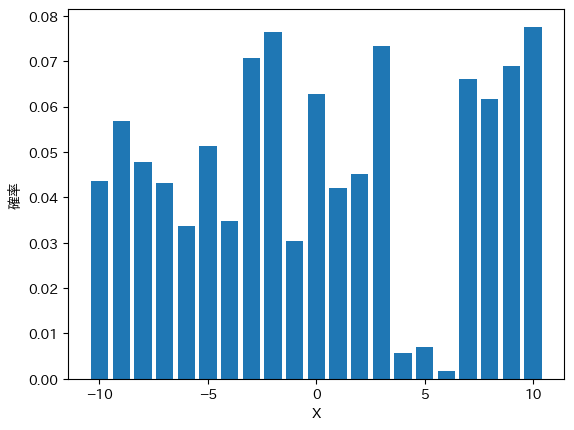

In [4]:
show_pd(X, P)

c:\Users\ys\Anaconda3\envs\marubatsu313\Lib\site-packages\numpy\lib\_stride_tricks_impl.py:542: UserWarning: Warning: converting a masked element to nan.
  args = [np.array(_m, copy=None, subok=subok) for _m in args]


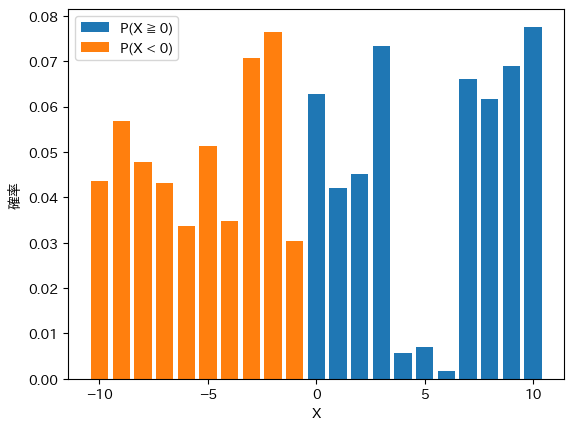

In [5]:
Ppos = np.ma.array(P, mask=X<0)
Pneg = np.ma.array(P, mask=X>=0)
plt.bar(X, Ppos, label="P(X ≧ 0)")
plt.bar(X, Pneg, label="P(X < 0)")
plt.xlabel("X")
plt.ylabel("確率")
plt.legend()
plt.show()

c:\Users\ys\Anaconda3\envs\marubatsu313\Lib\site-packages\matplotlib\cbook.py:1719: UserWarning: Warning: converting a masked element to nan.
  return math.isfinite(val)


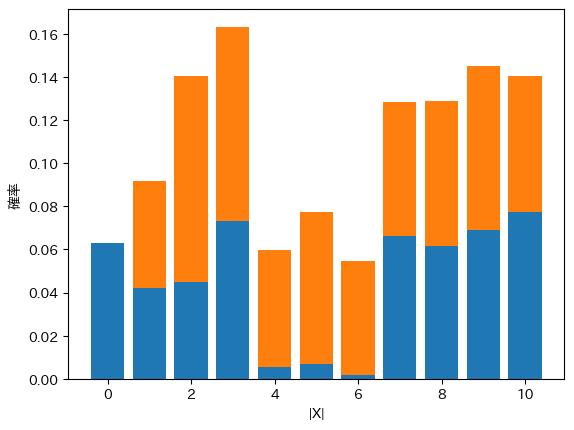

In [6]:
Preverseneg = Pneg[::-1]
plt.bar(X, Ppos)
plt.bar(X, Preverseneg, bottom=Ppos)
plt.xlabel("|X|")
plt.ylabel("確率")
plt.show()

In [7]:
def calc_abs_pd(X, P):
    maxx = max(max(X), max(-X))
    Xabs = np.arange(0, maxx + 1)
    Pabs = np.zeros_like(Xabs, dtype=np.float32)
    for x, p in zip(X, P):
        Pabs[abs(x)] += p
    return Xabs, Pabs

期待値 =  5.394
分散   = 10.779


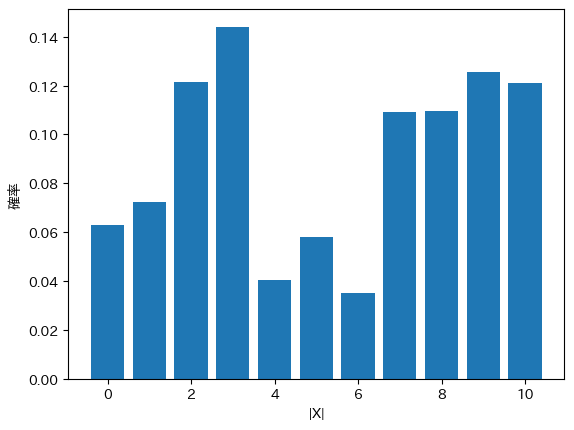

In [8]:
Xabs, Pabs = calc_abs_pd(X, P)
show_pd(Xabs, Pabs, xlabel="|X|")

In [ ]:
def show_pd(X, P, xlabel="X", cond=None, labelt="", labelf=""):
    E = np.sum(X * P)
    V = np.sum(X * X * P) - E ** 2
    print(f"期待値 = {E:6.3f}")
    print(f"分散   = {V:6.3f}")
    if cond is None:
        plt.bar(X, P)
    else:
        Pfalse = np.ma.array(P, mask=cond)
        Ptrue = np.ma.array(P, mask=~cond)
        plt.bar(X, Pfalse, label=labelf)
        plt.bar(X, Ptrue, label=labelt)
        plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel("確率")
    plt.show()

期待値 =  0.149
分散   = 39.856


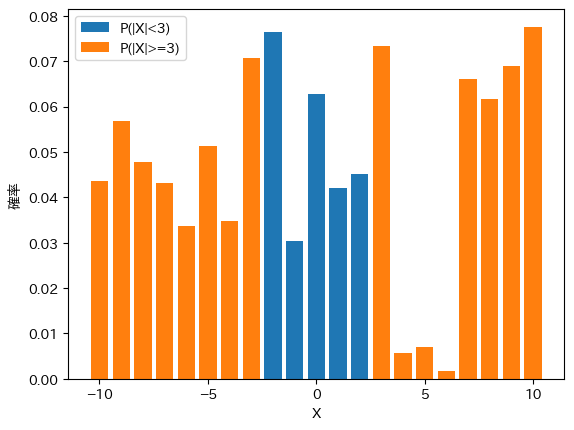

期待値 =  5.394
分散   = 10.779


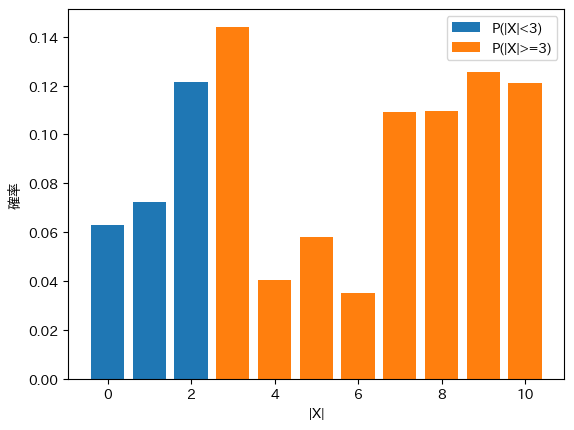

期待値 =  0.149
分散   = 39.856


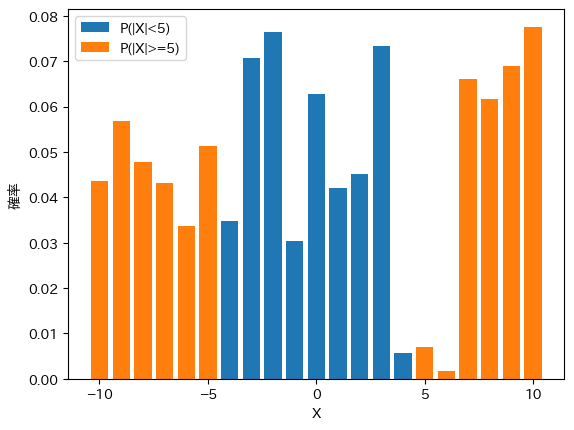

期待値 =  5.394
分散   = 10.779


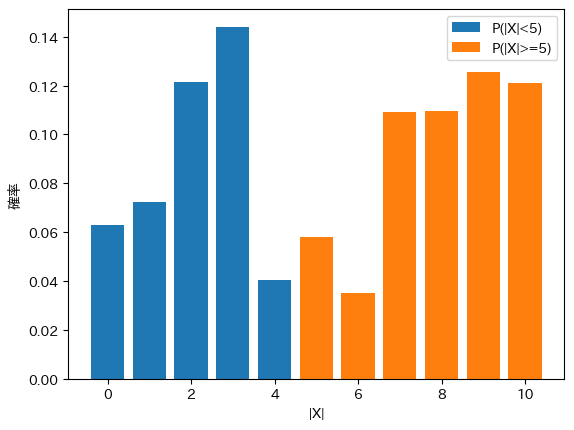

期待値 =  0.149
分散   = 39.856


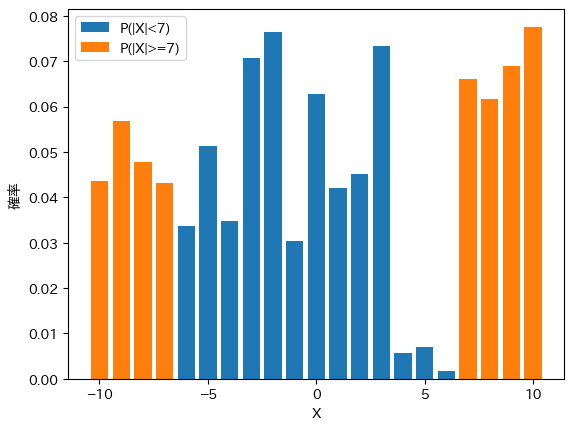

期待値 =  5.394
分散   = 10.779


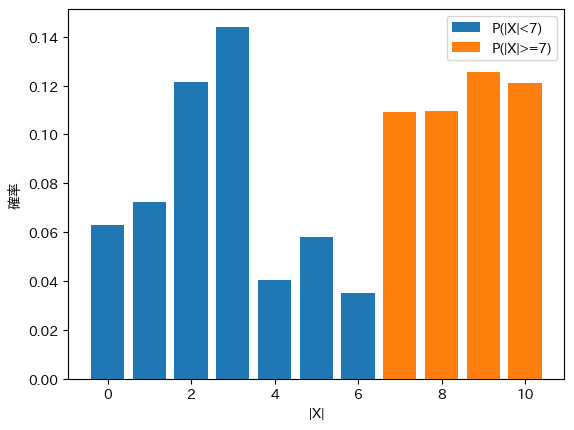

In [10]:
for a in [3, 5, 7]:
    labelt = f"P(|X|>={a})"
    labelf = f"P(|X|<{a})"
    show_pd(X, P, cond=np.abs(X)>=a, labelt=labelt, labelf=labelf)
    show_pd(Xabs, Pabs, xlabel="|X|", cond=Xabs>=a, labelt=labelt, labelf=labelf)

In [11]:
X2 = np.array([-3, -2, -1, 0, 1, 2, 3])
P2 = np.array([0.2, 0.1, 0.25, 0.15, 0.05, 0.1, 0.15])
Xabs2, Pabs2 = calc_abs_pd(X2, P2)
for x, p in zip(Xabs2, Pabs2):
    print(f"P(|X| = {x}) = {p:.2f}")

P(|X| = 0) = 0.15
P(|X| = 1) = 0.30
P(|X| = 2) = 0.20
P(|X| = 3) = 0.35


In [12]:
def check_markov(X, P, maxa):
    Xabs, Pabs = calc_abs_pd(X, P)
    Eabs = np.sum(Xabs * Pabs)
    Vabs = np.sum(Xabs * Xabs * Pabs) - Eabs ** 2
    print(f"E[|X|] = {Eabs:6.3f}")
    print(f"V[|X|] = {Vabs:6.3f}")
    for a in range(1, maxa + 1):
        Pgta = np.ma.array(Pabs, mask=Xabs<a)
        p = np.sum(Pgta)
        print(f"P(|X| ≧ {a:2d}) = {p:.3f} E[|X|]/{a:2d} = {Eabs/a:4.3f} {p <= Eabs/a}")

In [13]:
check_markov(X2, P2, 3)

E[|X|] =  1.750
V[|X|] =  1.187
P(|X| ≧  1) = 0.850 E[|X|]/ 1 = 1.750 True
P(|X| ≧  2) = 0.550 E[|X|]/ 2 = 0.875 True
P(|X| ≧  3) = 0.350 E[|X|]/ 3 = 0.583 True


In [14]:
check_markov(X, P, 10)

E[|X|] =  5.394
V[|X|] = 10.779
P(|X| ≧  1) = 0.937 E[|X|]/ 1 = 5.394 True
P(|X| ≧  2) = 0.865 E[|X|]/ 2 = 2.697 True
P(|X| ≧  3) = 0.743 E[|X|]/ 3 = 1.798 True
P(|X| ≧  4) = 0.599 E[|X|]/ 4 = 1.349 True
P(|X| ≧  5) = 0.559 E[|X|]/ 5 = 1.079 True
P(|X| ≧  6) = 0.501 E[|X|]/ 6 = 0.899 True
P(|X| ≧  7) = 0.466 E[|X|]/ 7 = 0.771 True
P(|X| ≧  8) = 0.356 E[|X|]/ 8 = 0.674 True
P(|X| ≧  9) = 0.247 E[|X|]/ 9 = 0.599 True
P(|X| ≧ 10) = 0.121 E[|X|]/10 = 0.539 True


期待値 =  3.030
分散   = 38.872


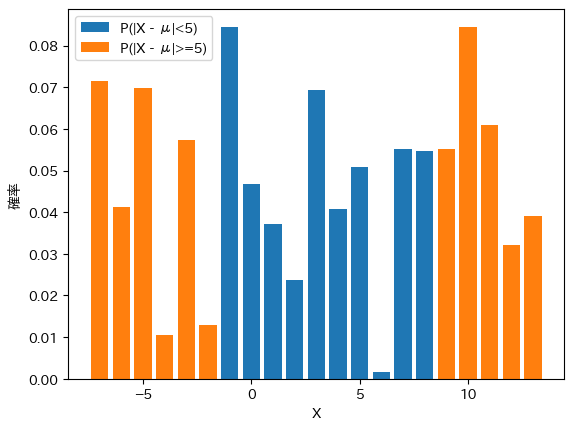

In [15]:
X3, P3 = create_pd(minx=-7, maxx=13)
E = np.sum(X3 * P3)
labelt = f"P(|X - μ|>={5})"
labelf = f"P(|X - μ|<{5})"
show_pd(X3, P3, cond=np.abs(X3 - E)>=5, labelt=labelt, labelf=labelf)

In [16]:
def check_chebyshev(X, P, maxa):
    E = np.sum(X * P)
    V = np.sum(X * X * P) - E ** 2
    print(f"E[X] = {E:6.3f}")
    print(f"V[X] = {V:6.3f}")
    for a in range(1, maxa + 1):
        Pgta = np.ma.array(P, mask=np.abs(X - E)<a)
        p = np.sum(Pgta)
        print(f"P(|X - E[X]| ≧ {a:2d}) = {p:.3f}  V[X]/{(a ** 2):3d} = {V/(a ** 2):6.3f} {p <= V/a/a}")

In [17]:
check_chebyshev(X3, P3, 10)

E[X] =  3.030
V[X] = 38.872
P(|X - E[X]| ≧  1) = 0.890  V[X]/  1 = 38.872 True
P(|X - E[X]| ≧  2) = 0.815  V[X]/  4 =  9.718 True
P(|X - E[X]| ≧  3) = 0.777  V[X]/  9 =  4.319 True
P(|X - E[X]| ≧  4) = 0.675  V[X]/ 16 =  2.429 True
P(|X - E[X]| ≧  5) = 0.535  V[X]/ 25 =  1.555 True
P(|X - E[X]| ≧  6) = 0.467  V[X]/ 36 =  1.080 True
P(|X - E[X]| ≧  7) = 0.326  V[X]/ 49 =  0.793 True
P(|X - E[X]| ≧  8) = 0.254  V[X]/ 64 =  0.607 True
P(|X - E[X]| ≧  9) = 0.152  V[X]/ 81 =  0.480 True
P(|X - E[X]| ≧ 10) = 0.072  V[X]/100 =  0.389 True
